# Part 1: Neural Network Fundamentals and Training Behavior Analysis

## 1. Importing Required Libraries

In [1]:
# =========================
# Import Required Libraries
# =========================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

import warnings
warnings.filterwarnings('ignore')

# Plot styling
sns.set_style("whitegrid")

print("Libraries imported successfully!")

Libraries imported successfully!


## 2. Loading the Dataset

In [3]:
# =========================
# Load Dataset
# =========================

# Replace with your actual dataset filename
df = pd.read_csv("customer_churn_nn.csv")

# Display first 5 rows
df.head()

,customer_id,region,plan_type,contract_type,payment_method,tenure_months,monthly_charges_inr,avg_login_days_per_month,support_tickets_last_90_days,payment_delay_days,data_usage_gb,satisfaction_score,last_complaint_days_ago,discount_percent,autopay_enabled,referral_count,churn
0,CUST0001,South,Standard,Month-to-month,Debit Card,30,687.40,13,0,0,87.97,8.0,67,0,0,0,0
1,CUST0002,West,Premium,Month-to-month,Wallet,15,1029.74,22,3,1,82.17,5.7,69,0,0,0,0
2,CUST0003,Central,Standard,Month-to-month,Credit Card,72,732.07,13,0,11,89.39,6.4,63,10,0,0,0
3,CUST0004,West,Premium,Month-to-month,Credit Card,22,959.51,19,2,3,139.73,7.2,130,5,0,0,0
4,CUST0005,North,Premium,Month-to-month,Net Banking,11,890.20,18,2,6,156.43,5.8,0,5,1,2,0


## 3. Dataset Understanding and Exploration

### 3.1 Dataset Shape

### 3.2 Dataset Information

In [4]:
# =========================
# Dataset Shape
# =========================

print("Number of Rows :", df.shape[0])
print("Number of Columns :", df.shape[1])

Number of Rows : 2000
Number of Columns : 17


In [5]:
# =========================
# Dataset Information
# =========================

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   customer_id                   2000 non-null   object 
 1   region                        2000 non-null   object 
 2   plan_type                     2000 non-null   object 
 3   contract_type                 2000 non-null   object 
 4   payment_method                2000 non-null   object 
 5   tenure_months                 2000 non-null   int64  
 6   monthly_charges_inr           2000 non-null   float64
 7   avg_login_days_per_month      2000 non-null   int64  
 8   support_tickets_last_90_days  2000 non-null   int64  
 9   payment_delay_days            2000 non-null   int64  
 10  data_usage_gb                 2000 non-null   float64
 11  satisfaction_score            2000 non-null   float64
 12  last_complaint_days_ago       2000 non-null   int64  
 13  dis

### 3.3 Missing Value Analysis

### 3.4 Statistical Summary

In [6]:
# =========================
# Missing Value Analysis
# =========================

missing_values = df.isnull().sum()

print("Missing Values in Each Column:\n")
print(missing_values)

Missing Values in Each Column:

customer_id                     0
region                          0
plan_type                       0
contract_type                   0
payment_method                  0
tenure_months                   0
monthly_charges_inr             0
avg_login_days_per_month        0
support_tickets_last_90_days    0
payment_delay_days              0
data_usage_gb                   0
satisfaction_score              0
last_complaint_days_ago         0
discount_percent                0
autopay_enabled                 0
referral_count                  0
churn                           0
dtype: int64


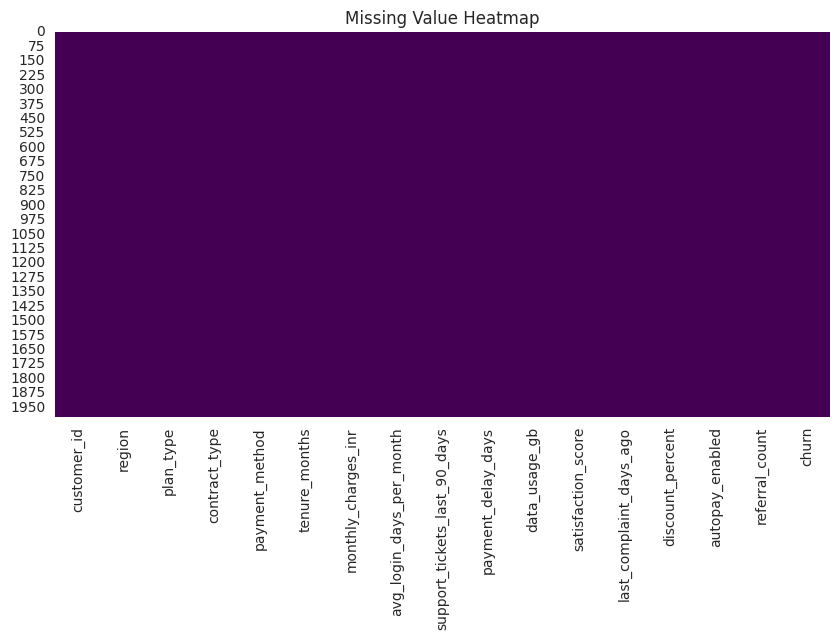

In [7]:
# Visualize Missing Values

plt.figure(figsize=(10,5))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')

plt.title("Missing Value Heatmap")
plt.show()

In [8]:
# =========================
# Statistical Summary
# =========================

df.describe(include='all')

,customer_id,region,plan_type,contract_type,payment_method,tenure_months,monthly_charges_inr,avg_login_days_per_month,support_tickets_last_90_days,payment_delay_days,data_usage_gb,satisfaction_score,last_complaint_days_ago,discount_percent,autopay_enabled,referral_count,churn
count,2000,2000,2000,2000,2000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
unique,2000,5,4,3,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,CUST1984,West,Standard,Month-to-month,Credit Card,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,417,718,1111,411,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,25.362000,766.487295,18.099000,1.953000,3.555000,90.007625,6.87395,46.616500,8.255000,0.597500,0.918000,0.015500
std,NaN,NaN,NaN,NaN,NaN,14.128651,393.420070,5.400628,1.463852,3.885682,53.215719,1.52428,55.065775,7.553708,0.490524,1.041546,0.123561
min,NaN,NaN,NaN,NaN,NaN,1.000000,255.450000,0.000000,0.000000,0.000000,0.500000,1.00000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,NaN,NaN,NaN,NaN,NaN,15.000000,427.782500,15.000000,1.000000,1.000000,51.777500,5.87500,6.000000,0.000000,0.000000,0.000000,0.000000
50%,NaN,NaN,NaN,NaN,NaN,23.000000,688.355000,18.000000,2.000000,2.000000,80.245000,6.80000,28.500000,5.000000,1.000000,1.000000,0.000000
75%,NaN,NaN,NaN,NaN,NaN,33.000000,1007.372500,22.000000,3.000000,5.000000,119.097500,8.00000,68.000000,15.000000,1.000000,1.000000,0.000000


### Interpretation

- The dataset contains **2000 rows and 17 columns**, indicating a moderately sized structured dataset suitable for neural network training.
- Both categorical and numerical features are present in the dataset. Categorical columns include variables such as `region`, `plan_type`, `contract_type`, and `payment_method`, while the remaining columns are numerical.
- The target variable for this problem is `churn`, which represents whether a customer has churned or not. Since the target variable is binary, this is a **binary classification problem**.
- The dataset does not contain any missing values, which simplifies the preprocessing stage and ensures better training consistency.
- Statistical analysis shows variation across features such as monthly charges, tenure, login frequency, payment delays, and satisfaction scores, indicating that these features may significantly influence customer churn prediction.
- Since the numerical features have different ranges and scales, feature scaling will be required before training the neural network model.

### 3.5 Feature Type Analysis

### 3.6 Target Variable Distribution

In [9]:
# =========================
# Feature Type Analysis
# =========================

categorical_cols = df.select_dtypes(include=['object']).columns
numerical_cols = df.select_dtypes(exclude=['object']).columns

print("Categorical Columns:\n")
print(list(categorical_cols))

print("\nNumerical Columns:\n")
print(list(numerical_cols))

Categorical Columns:

['customer_id', 'region', 'plan_type', 'contract_type', 'payment_method']

Numerical Columns:

['tenure_months', 'monthly_charges_inr', 'avg_login_days_per_month', 'support_tickets_last_90_days', 'payment_delay_days', 'data_usage_gb', 'satisfaction_score', 'last_complaint_days_ago', 'discount_percent', 'autopay_enabled', 'referral_count', 'churn']


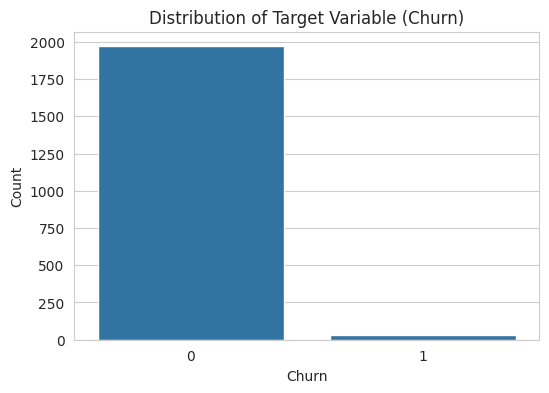

churn
0    1969
1      31
Name: count, dtype: int64


In [10]:
# =========================
# Target Variable Distribution
# =========================

plt.figure(figsize=(6,4))

sns.countplot(x=df['churn'])

plt.title("Distribution of Target Variable (Churn)")
plt.xlabel("Churn")
plt.ylabel("Count")

plt.show()

# Display class counts
print(df['churn'].value_counts())

### Interpretation

- The dataset contains both categorical and numerical features. Categorical variables such as `region`, `plan_type`, `contract_type`, and `payment_method` will require encoding before neural network training.
- The `customer_id` column is only a unique identifier and does not provide meaningful predictive information, so it will be removed during preprocessing.
- The target variable `churn` is binary, confirming that this is a binary classification problem.
- From the target distribution plot, the dataset is highly imbalanced. Out of 2000 records, approximately 1969 belong to class `0` (non-churn) while only 31 belong to class `1` (churn).
- Such class imbalance can affect neural network learning because the model may become biased toward the majority class.
- During model evaluation, metrics beyond accuracy such as confusion matrix and classification report will be important to better understand model performance on the minority class.

# 4. Data Preprocessing

### 4.1 Removing Unnecessary Columns

### 4.2 Encoding Categorical Features

### 4.3 Feature and Target Separation

### 4.4 Feature Scaling

### 4.5 Train-Test Split

In [11]:
# =========================
# Remove Unnecessary Columns
# =========================

df = df.drop("customer_id", axis=1)

print("customer_id column removed successfully.")

customer_id column removed successfully.


In [12]:
# =========================
# Encode Categorical Features
# =========================

label_encoder = LabelEncoder()

categorical_cols = ['region', 'plan_type', 'contract_type', 'payment_method']

for col in categorical_cols:
    df[col] = label_encoder.fit_transform(df[col])

print("Categorical columns encoded successfully.")

Categorical columns encoded successfully.


In [14]:
# =========================
# Separate Features and Target
# =========================

X = df.drop("churn", axis=1)
y = df["churn"]

print("Feature matrix shape :", X.shape)
print("Target vector shape :", y.shape)

Feature matrix shape : (2000, 15)
Target vector shape : (2000,)


In [15]:
# =========================
# Feature Scaling
# =========================

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Features scaled successfully.")

Features scaled successfully.


In [16]:
# =========================
# Train-Test Split
# =========================

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data Shape :", X_train.shape)
print("Testing Data Shape :", X_test.shape)

Training Data Shape : (1600, 15)
Testing Data Shape : (400, 15)


### Interpretation

- The `customer_id` column was removed because it is only a unique identifier and does not provide meaningful information for predicting customer churn.
- Categorical features such as `region`, `plan_type`, `contract_type`, and `payment_method` were converted into numerical format using Label Encoding to make them suitable for neural network processing.
- The feature matrix contains 15 input variables, while the target variable `churn` represents the output class for prediction.
- Feature scaling was performed using `StandardScaler` to normalize feature values and improve neural network training stability and convergence speed.
- The dataset was divided into training and testing sets using an 80:20 split ratio.
- The training dataset contains 1600 samples, while the testing dataset contains 400 samples for evaluating model generalization performance.

# 5. Neural Network Model Building

### 5.1 Building the Feed-Forward Neural Network

In [17]:
# =========================
# Build Neural Network Model
# =========================

model = Sequential()

# Hidden Layer
model.add(Dense(
    16,
    input_dim=X_train.shape[1],
    activation='relu'
))

# Output Layer
model.add(Dense(
    1,
    activation='sigmoid'
))

# Compile Model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("Neural Network Model Built Successfully!")

Neural Network Model Built Successfully!


In [18]:
# =========================
# Model Summary
# =========================

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 273 (1.07 KB)

 Trainable params: 273 (1.07 KB)

 Non-trainable params: 0 (0.00 B)

### Interpretation

- The neural network model consists of one hidden layer and one output layer.
- The hidden layer contains 16 neurons with ReLU activation, enabling the model to learn complex and non-linear relationships between customer attributes and churn behavior.
- The output layer contains 1 neuron with Sigmoid activation, which is suitable for binary classification problems because it outputs probabilities between 0 and 1.
- The model contains a total of 273 trainable parameters, including weights and biases that are updated during training through backpropagation.
- The architecture is lightweight and computationally efficient, making it appropriate for structured tabular data classification tasks.

# 6. Model Training and Evaluation

### 6.1 Training the Neural Network

In [19]:
# =========================
# Train the Neural Network
# =========================

history = model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.5820 - loss: 0.6909 - val_accuracy: 0.7281 - val_loss: 0.5682
Epoch 2/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8438 - loss: 0.4814 - val_accuracy: 0.8875 - val_loss: 0.4135
Epoch 3/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9531 - loss: 0.3496 - val_accuracy: 0.9594 - val_loss: 0.3157
Epoch 4/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9812 - loss: 0.2650 - val_accuracy: 0.9719 - val_loss: 0.2530
Epoch 5/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9852 - loss: 0.2102 - val_accuracy: 0.9781 - val_loss: 0.2108
Epoch 6/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9867 - loss: 0.1731 - val_accuracy: 0.9781 - val_loss: 0.1811
Epoch 7/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9867 - loss: 0.1473 - val_accuracy: 0.9781 - val_loss: 0.1606
Epoch 8/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9867 - loss: 0.1291 - val_accuracy: 0.9781 - val_loss:

### Interpretation

- The neural network model was trained for 30 epochs using the Adam optimizer and Binary Crossentropy loss function.
- During training, the loss value consistently decreased while accuracy improved, indicating successful learning and parameter optimization.
- The model achieved high training and validation accuracy, showing that the neural network was able to capture meaningful patterns related to customer churn.
- Validation loss gradually decreased across epochs, suggesting stable convergence during training.
- The final validation accuracy reached approximately 97%, indicating strong predictive performance on unseen validation data.
- Since both training and validation performance remained consistently high without large divergence, the model does not currently show strong signs of overfitting.

### 6.2 Training Performance Visualization

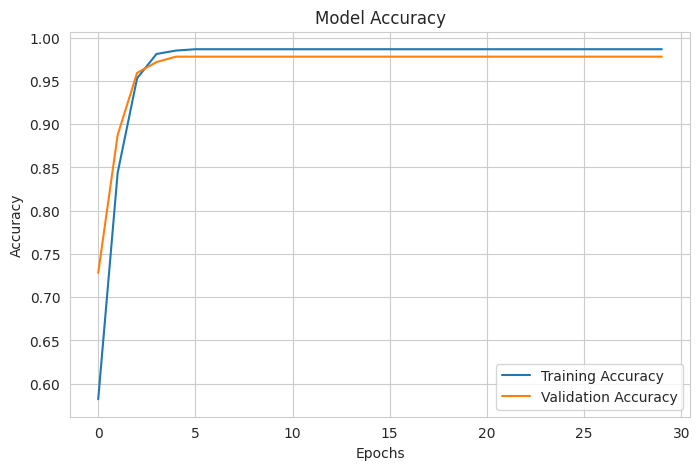

In [20]:
# =========================
# Accuracy Plot
# =========================

plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Model Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")

plt.legend()

plt.show()

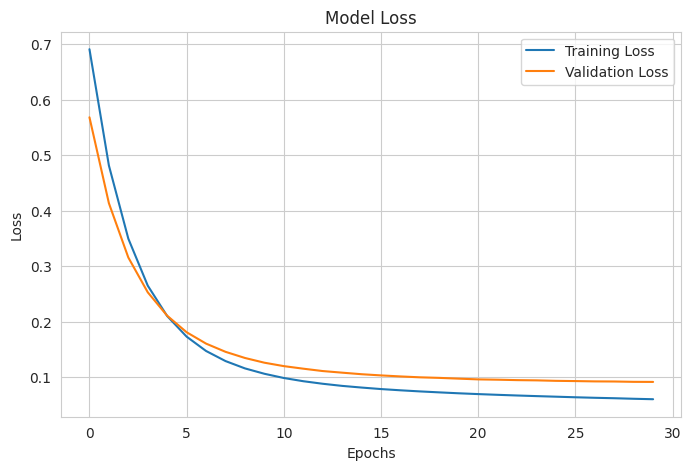

In [21]:
# =========================
# Loss Plot
# =========================

plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Model Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")

plt.legend()

plt.show()

### Interpretation

- The accuracy plot shows a rapid improvement in both training and validation accuracy during the initial epochs, indicating effective learning by the neural network.
- After a few epochs, both curves stabilized near 98% accuracy, suggesting that the model successfully converged.
- The loss plot demonstrates a continuous decrease in both training and validation loss values, which indicates that prediction errors reduced steadily during training.
- The training and validation curves remain closely aligned throughout the epochs, showing that the model generalized well and did not significantly overfit the training data.
- The smooth convergence pattern confirms that the selected optimizer, learning rate, and network architecture were appropriate for this classification problem.

### 6.3 Model Evaluation on Test Data

In [22]:
# =========================
# Evaluate Model on Test Data
# =========================

test_loss, test_accuracy = model.evaluate(X_test, y_test)

print("Test Loss :", test_loss)
print("Test Accuracy :", test_accuracy)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9825 - loss: 0.0841  
Test Loss : 0.08407431840896606
Test Accuracy : 0.9825000166893005


In [23]:
# =========================
# Generate Predictions
# =========================

y_pred_prob = model.predict(X_test)

# Convert probabilities into binary predictions
y_pred = (y_pred_prob > 0.5).astype(int)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


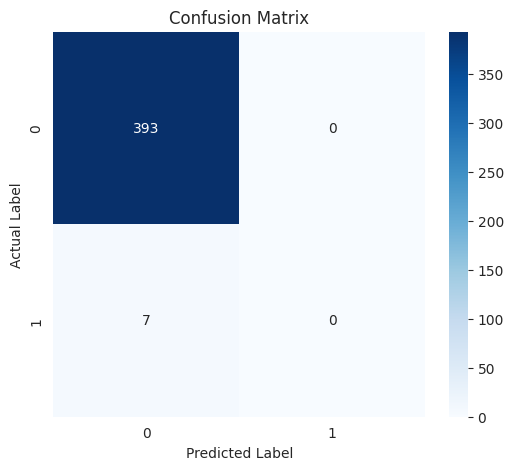

In [24]:
# =========================
# Confusion Matrix
# =========================

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

In [25]:
# =========================
# Classification Report
# =========================

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99       393
           1       0.00      0.00      0.00         7

    accuracy                           0.98       400
   macro avg       0.49      0.50      0.50       400
weighted avg       0.97      0.98      0.97       400



### Interpretation

- The neural network achieved a test accuracy of approximately 98%, indicating strong overall prediction performance on the test dataset.
- The confusion matrix shows that the model correctly classified most non-churn customers (class 0).
- However, the model failed to correctly identify churn customers (class 1), as all churn cases were predicted as non-churn.
- This behavior occurred because the dataset is highly imbalanced, with significantly fewer churn samples compared to non-churn samples.
- Although the overall accuracy is high, the recall and F1-score for the churn class are very low, showing poor minority class detection capability.
- This demonstrates that accuracy alone may not be sufficient for evaluating imbalanced classification problems.
- Additional techniques such as class balancing, oversampling, undersampling, or class weighting could improve minority class prediction performance in future experiments.

# 7. Hyperparameter Experimentation

### 7.1 Experiment 1 - Baseline Model

### 7.2 Experiment 2 - Increased Neurons

### 7.3 Experiment 3 - Different Activation Function

In [26]:
# =========================
# Experiment 2 - More Neurons
# =========================

model_exp2 = Sequential()

model_exp2.add(Dense(
    32,
    input_dim=X_train.shape[1],
    activation='relu'
))

model_exp2.add(Dense(
    1,
    activation='sigmoid'
))

model_exp2.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history_exp2 = model_exp2.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.2,
    verbose=0
)

loss_exp2, acc_exp2 = model_exp2.evaluate(X_test, y_test, verbose=0)

print("Experiment 2 Test Accuracy :", acc_exp2)

Experiment 2 Test Accuracy : 0.9825000166893005


In [27]:
# =========================
# Experiment 3 - Tanh Activation
# =========================

model_exp3 = Sequential()

model_exp3.add(Dense(
    16,
    input_dim=X_train.shape[1],
    activation='tanh'
))

model_exp3.add(Dense(
    1,
    activation='sigmoid'
))

model_exp3.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history_exp3 = model_exp3.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.2,
    verbose=0
)

loss_exp3, acc_exp3 = model_exp3.evaluate(X_test, y_test, verbose=0)

print("Experiment 3 Test Accuracy :", acc_exp3)

Experiment 3 Test Accuracy : 0.9825000166893005


### 7.4 Hyperparameter Comparison Table

In [28]:
# =========================
# Hyperparameter Comparison Table
# =========================

comparison_df = pd.DataFrame({
    "Experiment": [
        "Baseline Model",
        "Increased Neurons",
        "Tanh Activation"
    ],

    "Hidden Layer Configuration": [
        "16 Neurons",
        "32 Neurons",
        "16 Neurons"
    ],

    "Activation Function": [
        "ReLU",
        "ReLU",
        "Tanh"
    ],

    "Epochs": [
        30,
        30,
        30
    ],

    "Test Accuracy": [
        test_accuracy,
        acc_exp2,
        acc_exp3
    ]
})

comparison_df

,Experiment,Hidden Layer Configuration,Activation Function,Epochs,Test Accuracy
0,Baseline Model,16 Neurons,ReLU,30,0.9825
1,Increased Neurons,32 Neurons,ReLU,30,0.9825
2,Tanh Activation,16 Neurons,Tanh,30,0.9825


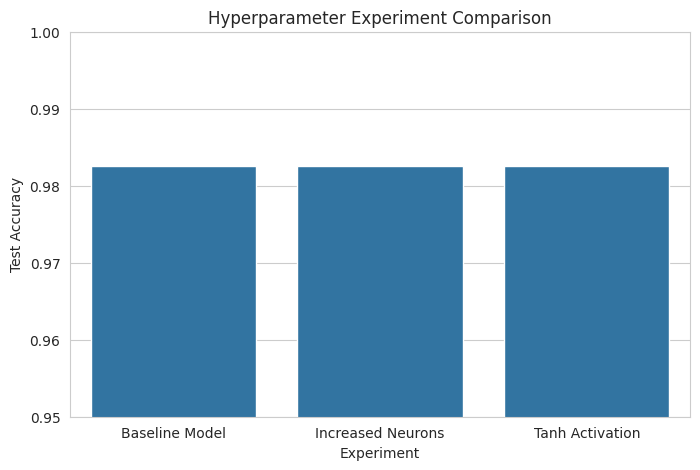

In [29]:
# =========================
# Accuracy Comparison Plot
# =========================

plt.figure(figsize=(8,5))

sns.barplot(
    x="Experiment",
    y="Test Accuracy",
    data=comparison_df
)

plt.title("Hyperparameter Experiment Comparison")
plt.ylim(0.95, 1.0)

plt.show()

### Interpretation

- Multiple experiments were conducted by modifying neural network hyperparameters such as the number of neurons and activation functions.
- Increasing the number of neurons from 16 to 32 did not significantly improve model accuracy.
- Replacing the ReLU activation function with Tanh also produced similar performance results.
- The experiments suggest that the dataset characteristics and class imbalance had a larger impact on performance than small architectural changes.
- Although overall accuracy remained high across all experiments, the imbalance problem continued to affect minority class prediction performance.
- Hyperparameter experimentation is important because it helps analyze how different network configurations influence model learning behavior and generalization capability.

In [30]:
# Save comparison table as CSV

comparison_df.to_csv("model_comparison_table.csv", index=False)

print("Comparison table saved successfully.")

Comparison table saved successfully.


# 8. Final Reflection

## Role of Weights and Biases

The trainable parameters of a neural network are called weights and biases. Weights assign values to the contribution of each input feature in prediction, while biases help shift the activation value and increase the flexibility of the model. During the training process, these parameters are continuously updated using backpropagation and gradient descent to reduce prediction error.

## Importance of Activation Functions

Activation functions are used to introduce non-linearity into the neural network, enabling it to learn complex relationships between input features and the target variable. Without activation functions, the neural network would behave like a traditional linear model and would not be able to effectively solve complex classification problems.

## Effect of Learning Rate

The learning rate controls the magnitude of parameter updates during training.

- If the learning rate is too high, the model may overshoot the optimal solution and training may become unstable.
- If the learning rate is too low, the model learns very slowly and training may take excessive time to converge.

Therefore, selecting an appropriate learning rate is essential for stable and efficient model optimization.

## Underfitting and Overfitting Analysis

The model achieved high training and validation accuracy while the loss value decreased steadily throughout training, indicating effective learning behavior. The training and validation curves remained closely aligned, suggesting that significant overfitting was not observed.

However, due to the highly imbalanced dataset, the model struggled to correctly classify minority churn cases. This indicates that although the overall model performance was strong, its generalization capability for the minority class remained limited.